# Collapsing Threshold Models: A Parameter Recovery Simulation | [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AmirHoseinHadian/JEAM/blob/main/docs/notebooks/05_Collapsing_Threshold_Models.ipynb)
[View the notebook on GitHub](https://github.com/AmirHoseinHadian/JEAM/blob/main/docs/notebooks/05_Collapsing_Threshold_Models.ipynb)

This tutorial illustrates how to use CRDDM to fit **collapsing threshold diffusion models** and to fit a joint model on observed data from multiple sources (e.g., behavior and neural signals). 

This tutorial contains a simple **parameter recovery** study using **Circular Diffusion Model (CDM)** with a
**linear collapsing decision threshold**. We considered two setups for parameter recovery:

1. **Uninformed collapsing-threshold model**: fit the model using only choice/RT data.

2. **NDT-informed collapsing-threshold model (joint modeling)**: fit the model using choice/RT data **and**
   additional measurements that inform the non-decision time (NDT) distribution.
   
---

In [ ]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("jeam") is None:
    subprocess.check_call(
        [sys.executable, 
         "-m", 
         "pip", 
         "install", 
         "--quiet", 
         "git+https://github.com/AmirHoseinHadian/JEAM.git@main"]
    )

## Import required packages

In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution

from jeam.Models.Circular import CircularDiffusionModel as CDM

## 1. Uninformed collapsing threshold diffusion models:

In the first setup, we simulate data from a CDM with a **linear collapsing threshold** and then recover:

- `threshold`: initial decision threshold,
- `decay`: collapse rate (linear),
- `ndt`: non-decision time,
- `mu_x, mu_y`: drift vector components.

### 1.1 Negative log-likelihood

In [2]:
def negative_log_likelihood(params, rt, theta, model):
    threshold = params[0]            # initial decision threshold
    decay = params[1]                # decay rate of threshold
    ndt = params[2]                  # non-decision time
    drift_vec = np.array([params[3], params[4]])  # drift vector
    
    logpdf = model.joint_lpdf(rt, theta, drift_vec, ndt, threshold, decay=decay)
    
    return -np.sum(logpdf)

### 1.2 Simulation setup

In [3]:
n_trials = 500

recovery_df = {
    "threshold_true": [], "threshold_estimate": [],
    "decay_true": [], "decay_estimate": [],
    "ndt_true": [], "ndt_estimate": [],
    "mu_x_true": [], "mu_x_estimate": [],
    "mu_y_true": [], "mu_y_estimate": []
}

# Bounds for estimation
min_threshold, max_threshold = 2, 5
min_decay, max_decay = 0.05, 2
min_ndt, max_ndt = 0, 1.5
min_mu, max_mu = -5, 5

prms_bounds = [
    (min_threshold, max_threshold),
    (min_decay, max_decay),
    (min_ndt, max_ndt),
    (min_mu, max_mu),
    (min_mu, max_mu),
]

model = CDM(threshold_dynamic='exponential')

### 1.3 Simulation and estimation loop

In [4]:
for n in tqdm(range(20)):
    # Random generative parameters
    threshold = np.random.uniform(min_threshold, max_threshold)
    decay = np.random.uniform(min_decay, max_decay)
    mu_x = np.random.uniform(min_mu, max_mu)
    mu_y = np.random.uniform(min_mu, max_mu)
    drift_vector = np.array([mu_x, mu_y])
    ndt = np.random.uniform(min_ndt, max_ndt)
    
    # Simulating data with random generated parameters
    sim_df = model.simulate(
        drift_vector,
        ndt,
        threshold,
        decay=decay,
        n_sample=n_trials,
    )

    # Estimate parameters
    min_ans = differential_evolution(
        negative_log_likelihood,
        bounds=prms_bounds,
        args=(sim_df["rt"].values, sim_df["response"].values, model),
    )

    # Store true parameters
    recovery_df["threshold_true"].append(threshold)
    recovery_df["decay_true"].append(decay)
    recovery_df["ndt_true"].append(ndt)
    recovery_df["mu_x_true"].append(mu_x)
    recovery_df["mu_y_true"].append(mu_y)

    # Store estimates
    recovery_df["threshold_estimate"].append(min_ans.x[0])
    recovery_df["decay_estimate"].append(min_ans.x[1])
    recovery_df["ndt_estimate"].append(min_ans.x[2])
    recovery_df["mu_x_estimate"].append(min_ans.x[3])
    recovery_df["mu_y_estimate"].append(min_ans.x[4])

100%|███████████████████████████████████████████| 20/20 [03:40<00:00, 11.01s/it]


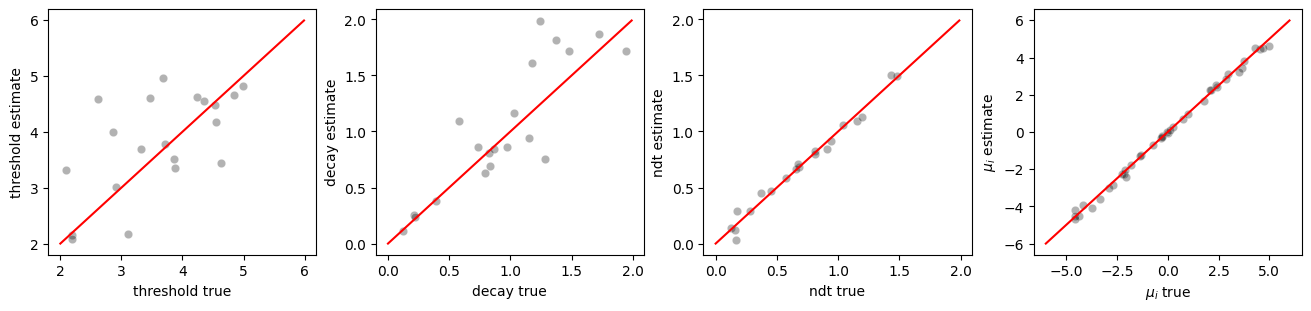

In [5]:
plt.figure(figsize=(13, 3), layout="constrained")

plt.subplot(141)
plt.plot(np.arange(2, 6, 0.01), np.arange(2, 6, 0.01), c="red")
sns.scatterplot(x="threshold_true", y="threshold_estimate", data=recovery_df, color="black", alpha=0.3)
plt.xlabel("threshold true")
plt.ylabel("threshold estimate")

plt.subplot(142)
plt.plot(np.arange(0, 2, 0.01), np.arange(0, 2, 0.01), c="red")
sns.scatterplot(x="decay_true", y="decay_estimate", data=recovery_df, color="black", alpha=0.3)
plt.xlabel("decay true")
plt.ylabel("decay estimate")

plt.subplot(143)
plt.plot(np.arange(0, 2, 0.01), np.arange(0, 2, 0.01), c="red")
sns.scatterplot(x="ndt_true", y="ndt_estimate", data=recovery_df, color="black", alpha=0.3)
plt.xlabel("ndt true")
plt.ylabel("ndt estimate")

plt.subplot(144)
plt.plot(np.arange(-6, 6, 0.01), np.arange(-6, 6, 0.01), c="red")
sns.scatterplot(x="mu_x_true", y="mu_x_estimate", data=recovery_df, color="black", alpha=0.3)
sns.scatterplot(x="mu_y_true", y="mu_y_estimate", data=recovery_df, color="black", alpha=0.3)
plt.xlabel(r"$\mu_i$ true")
plt.ylabel(r"$\mu_i$ estimate")
plt.show()

---

## 2. NDT-informed collapsing threshold diffusion models (joint modeling):

In many experiments, additional measurements can constrain the NDT distribution (e.g., encoding time,
motor time, or other process-pure measures). Here we demonstrate a simple joint model where:

- the diffusion model explains choice/RT data,
- a Gaussian measurement model explains observed `ndt_measurements`.

We recover:

- `threshold`, `decay`,
- `mean_ndt` and `sd_ndt`,
- `mu_x, mu_y`.

### 2.1 Negative joint log-likelihood

In [6]:
def negative_log_likelihood_ndt_informed(params, rt, theta, ndt_mesurements, model):
    threshold =  params[0]    # initial decision threshold
    decay = params [1]        # decay rate of threshold
    
    # mean of non-decision time measurements (shared across observation and diffusion model)
    mean_ndt = params[2] 
    sd_ndt = params[3] # SD of non-decision time measurements
    drift_vec = np.array([params[4], params[5]]) # drift vector
    
    ndt_logpdf = -0.5 * (ndt_mesurements - mean_ndt)**2/sd_ndt**2 - 0.5 * np.log(2*np.pi*sd_ndt**2)
    choice_logpdf = model.joint_lpdf(rt, theta, drift_vec, mean_ndt, threshold, decay=decay)
    
    return -np.sum(choice_logpdf) - np.sum(ndt_logpdf)

### 2.2 Simulation setup

In [7]:
n_trials = 500

recovery_df = {
    "threshold_true": [], "threshold_estimate": [],
    "decay_true": [], "decay_estimate": [],
    "mean_ndt_true": [], "mean_ndt_estimate": [],
    "sd_ndt_true": [], "sd_ndt_estimate": [],
    "mu_x_true": [], "mu_x_estimate": [],
    "mu_y_true": [], "mu_y_estimate": []
}

min_threshold, max_threshold = 2, 5
min_decay, max_decay = 0.05, 2
min_mean_ndt, max_mean_ndt = 0.05, 1.5
min_sd_ndt, max_sd_ndt = 0.01, 0.5
min_mu, max_mu = -5, 5

prms_bounds = [
    (min_threshold, max_threshold),
    (min_decay, max_decay),
    (min_mean_ndt, max_mean_ndt),   
    (min_sd_ndt, max_sd_ndt),
    (min_mu, max_mu),
    (min_mu, max_mu),
]

model = CDM(threshold_dynamic='exponential')

### 2.3 Simulation and estimation loop

In [8]:
for n in tqdm(range(20)):    
    # generating some random parameters
    threshold = np.random.uniform(min_threshold, max_threshold)
    decay = np.random.uniform(min_decay, max_decay)
    mu_x = np.random.uniform(min_mu, max_mu)
    mu_y = np.random.uniform(min_mu, max_mu)
    drift_vector = np.array([mu_x, mu_y])
    
    mean_ndt = np.random.uniform(0.05, max_ndt)
    sd_ndt = np.random.uniform(mean_ndt/5, mean_ndt/3)
    ndt_mesurements = mean_ndt + sd_ndt*np.random.randn(n_trials)
    
    sim_df = model.simulate(drift_vector, 
                            mean_ndt,
                            threshold, 
                            decay=decay,
                            n_sample=n_trials)
    
    # Estimating the paramters for the simulated data
    min_ans = differential_evolution(negative_log_likelihood_ndt_informed, 
                                     args=(sim_df['rt'].values, 
                                           sim_df['response'].values,
                                           ndt_mesurements,
                                           model), 
                                     bounds=prms_bounds)

    
    # Storing the true generating parameters
    recovery_df['threshold_true'].append(threshold)
    recovery_df['decay_true'].append(decay)
    recovery_df['mean_ndt_true'].append(mean_ndt)
    recovery_df['sd_ndt_true'].append(sd_ndt)
    recovery_df['mu_x_true'].append(mu_x)
    recovery_df['mu_y_true'].append(mu_y)
    
    # Stroing the estimated parameters
    recovery_df['threshold_estimate'].append(min_ans.x[0])
    recovery_df['decay_estimate'].append(min_ans.x[1])
    recovery_df['mean_ndt_estimate'].append(min_ans.x[2])
    recovery_df['sd_ndt_estimate'].append(min_ans.x[3])
    recovery_df['mu_x_estimate'].append(min_ans.x[4])
    recovery_df['mu_y_estimate'].append(min_ans.x[5])

100%|███████████████████████████████████████████| 20/20 [05:04<00:00, 15.22s/it]


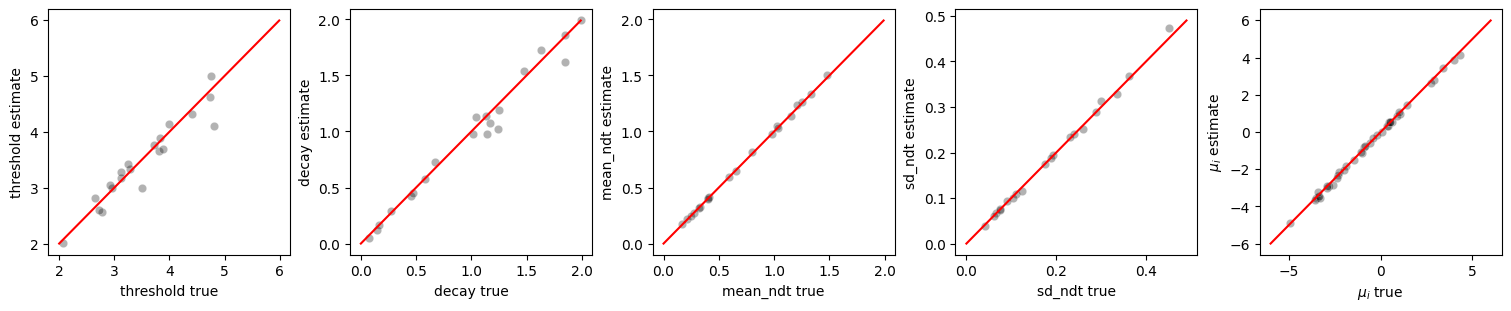

In [9]:
plt.figure(figsize=(15, 3), layout='constrained')

plt.subplot(151)
plt.plot(np.arange(2, 6, 0.01), np.arange(2, 6, 0.01), c='red')
sns.scatterplot(x='threshold_true', y='threshold_estimate', data=recovery_df, color='black', alpha=0.3);
plt.xlabel(r'threshold true')
plt.ylabel(r'threshold estimate')

plt.subplot(152)
plt.plot(np.arange(0, 2, 0.01), np.arange(0, 2, 0.01), c='red')
sns.scatterplot(x='decay_true', y='decay_estimate', data=recovery_df, color='black', alpha=0.3);
plt.xlabel(r'decay true')
plt.ylabel(r'decay estimate')

plt.subplot(153)
plt.plot(np.arange(0, 2, 0.01), np.arange(0, 2, 0.01), c='red')
sns.scatterplot(x='mean_ndt_true', y='mean_ndt_estimate', data=recovery_df, color='black', alpha=0.3);
plt.xlabel(r'mean_ndt true')
plt.ylabel(r'mean_ndt estimate')

plt.subplot(154)
plt.plot(np.arange(0, 0.5, 0.01), np.arange(0, 0.5, 0.01), c='red')
sns.scatterplot(x='sd_ndt_true', y='sd_ndt_estimate', data=recovery_df, color='black', alpha=0.3);
plt.xlabel(r'sd_ndt true')
plt.ylabel(r'sd_ndt estimate')

plt.subplot(155)
plt.plot(np.arange(-6, 6, 0.01), np.arange(-6, 6, 0.01), c='red')
sns.scatterplot(x='mu_x_true', y='mu_x_estimate', data=recovery_df, color='black', alpha=0.3);
sns.scatterplot(x='mu_y_true', y='mu_y_estimate', data=recovery_df, color='black', alpha=0.3);
plt.xlabel(r'$\mu_i$ true')
plt.ylabel(r'$\mu_i$ estimate');

---

## Notes


!!! warning "Always check parameter recovery"
    When introducing a new mapping function, mixture model, or joint model, **always perform a parameter
    recovery study** before applying the model to empirical data.

    Parameter recovery helps ensure that:
    - the likelihood function is implemented correctly,
    - parameters are identifiable given the data and design,
    - different model components (e.g., guessing vs. diffusion, threshold vs. NDT) are not confounded.

    Skipping this step can lead to misleading parameter estimates and incorrect theoretical conclusions.

---

## References

- Hadian Rasanan, A. H., Schumacher, L., Nunez, M. D., Weindel, G., & Rieskamp, J. (2025). Non-decision time-informed collapsing threshold diffusion model: A joint modeling framework with identifiable time-dependent parameters. *bioRxiv*, 2025-10. [https://doi.org/10.1101/2025.10.30.685574](https://doi.org/10.1101/2025.10.30.685574)

- Hadian Rasanan, A. H., Evans, N. J., Amani Rad, J., & Rieskamp, J. (2025). Parameter estimation of hyper-spherical diffusion models with a time-dependent threshold: An integral equation method. *Behavior Research Methods*, 57(10), 283. [https://doi.org/10.3758/s13428-025-02810-3](https://doi.org/10.3758/s13428-025-02810-3)